<a href="https://colab.research.google.com/github/jillianb2m/tcc-futebol-analise/blob/develop/tcc_ml_futebol.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 1. Installs & Imports

## 1.1. Installs

In [4]:
!pip install pingouin > /dev/null

## 1.2. Imports

In [5]:
import pandas as pd
import numpy as np
import traceback as tb
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from matplotlib.patches import FancyBboxPatch, Patch
from scipy.stats import zscore
import scipy.cluster.hierarchy as sch
import pingouin as pg
import plotly.express as px
import os

# 2. Configuração

In [12]:
# 5.2. Função main
%cd /content/tcc-futebol-analise
BASE_DIR = os.getcwd()

CONFIG = {
    'MIN_JOGOS': 5,
    'DATASET_PATH': os.path.join(BASE_DIR, 'datasets', 'processed', 'brasileirao_opta_final.csv'),
    'N_CLUSTERS_MAX': 10,
    'METODO_LINKAGE': 'complete',
    'METODO_PADRONIZAR': 'sklearn',
    'RANDOM_STATE': 100
}

# 5.1.1. Inicialização e gerar dataset base
regras_col_agregacao = {
    'rating': 'mean',
    'minutesPlayed': 'sum',
    'totalShots': 'mean',
    'onTargetScoringAttempt': 'mean',
    'bigChanceCreated': 'mean',
    'expectedGoals': 'mean',
    'goals': 'sum',
    'goalAssist': 'sum',
    'totalPass': 'mean',
    'accuratePass': 'mean',
    'keyPass': 'mean',
    'touches': 'mean',
    'possessionLostCtrl': 'mean',
    'totalTackle': 'mean',
    'interceptionWon': 'mean',
    'ballRecovery': 'mean',
    'wonTackle': 'mean',
    'aerialWon': 'mean',
    'Avg_X': 'mean',
    'Avg_Y': 'mean'
}

# 5.1.1. Inicialização e gerar dataset base
variaveis_esperadas = [
    'totalPass',
    'onTargetScoringAttempt',
    'bigChanceCreated',
    'expectedGoals',
    'accuratePass',
    'touches',
    'possessionLostCtrl',
    'ballRecovery',
    'totalShots',
    'goals',
    'totalTackle',
    'interceptionWon',
    'keyPass',
    'goalAssist',
    'aerialWon',
    'Avg_X',
    'Avg_Y'
]

# 5.1.2. Análise Exploratória
mapa_variaveis = {
    'rating': 'Avaliação',
    'minutesPlayed': 'Minutos Jogados',
    'totalPass': 'Total de passes',
    'onTargetScoringAttempt': 'Finalizações no alvo',
    'bigChanceCreated': 'Grandes chances criadas',
    'expectedGoals': 'Gols esperados (xG)',
    'accuratePass': 'Passes certos',
    'touches': 'Toques na bola',
    'possessionLostCtrl': 'Perdas de posse',
    'ballRecovery': 'Recuperações de bola',
    'totalShots': 'Finalizações',
    'goals': 'Gols',
    'totalTackle': 'Desarmes',
    'interceptionWon': 'Interceptações',
    'keyPass': 'Passes-chave',
    'goalAssist': 'Assistências',
    'aerialWon': 'Duelos aéreos ganhos',
    'wonTackle': 'Desarmes Ganhos',
    'Avg_X': 'Posição Horizontal',
    'Avg_Y': 'Posição Vertical'
}

# 5.1.2. Análise Exploratória
texto_legenda = (
    "Horizontal (Posição X):\n"
    "• 0 = Lado Esquerdo\n"
    "• 50 = Centro do Campo\n"
    "• 100 = Lado Direito\n\n"
    "Vertical (Posição Y):\n"
    "• 0 = Linha de Ataque\n"
    "• 50 = Linha do Meio Campo\n"
    "• 100 = Linha de Defesa\n\n"
    "Exemplos:\n"
    "• Goleiro: (50, 90)\n"
    "• Zagueiro: (50, 75)\n"
    "• Volante: (50, 60)\n"
    "• Meia: (50, 40)\n"
    "• Atacante: (50, 20)"
)

metricas_por_posicao = {
    'Goleiro': [
        'ballRecovery',
        'aerialWon',
        'totalPass',
        'accuratePass'
    ],
    'Zagueiro': [
        'aerialWon',
        'interceptionWon',
        'totalTackle',
        'ballRecovery'
    ],
    'Volante': [
        'totalTackle',
        'interceptionWon',
        'ballRecovery',
        'totalPass',
        'accuratePass'
    ],
    'Meia Central': [
        'keyPass',
        'goalAssist',
        'goals',
        'totalShots',
        'totalPass',
        'accuratePass',
        'touches',
        'ballRecovery',
        'interceptionWon',
        'wonTackle',
        'possessionLostCtrl'
    ]
}

# 6.1.2. Definição de benchmarks
regras_gap_agregacao = {
  'rating': 'mean',
  'goals': 'sum',
  'totalTackle': 'mean',
  'interceptionWon': 'mean',
  'ballRecovery': 'mean',
  'keyPass': 'mean',
  'goalAssist': 'sum',
  'totalPass': 'mean',
  'accuratePass': 'mean',
  'aerialWon': 'mean',
  'onTargetScoringAttempt': 'mean',
  'bigChanceCreated': 'mean',
  'expectedGoals': 'mean'
}

# 6.1.3. Regras para segunda agregação (média dos benchmarks)
regras_gap_agregacao_media = {
  'rating': 'mean',
  'goals': 'mean',
  'totalTackle': 'mean',
  'interceptionWon': 'mean',
  'ballRecovery': 'mean',
  'keyPass': 'mean',
  'goalAssist': 'mean',
  'totalPass': 'mean',
  'accuratePass': 'mean',
  'aerialWon': 'mean',
  'onTargetScoringAttempt': 'mean',
  'bigChanceCreated': 'mean',
  'expectedGoals': 'mean'
}

# 6.1.7. Perfil recomendado
mapeamento_perfis = {
    'Goleiro': {
        'ballRecovery': 'Defesa',
        'aerialWon': 'Defesa',
        'totalPass': 'Saída de Jogo',
        'accuratePass': 'Saída de Jogo'
    },
    'Zagueiro': {
        'aerialWon': 'Aéreo',
        'interceptionWon': 'Bola no Chão',
        'totalTackle': 'Bola no Chão',
        'ballRecovery': 'Bola no Chão'
    },
    'Volante': {
        'totalTackle': 'Defensivo',
        'interceptionWon': 'Defensivo',
        'ballRecovery': 'Defensivo',
        'totalPass': 'Organizador',
        'accuratePass': 'Organizador'
    },
    'Meia Central': {
        'keyPass': 'Criador',
        'goalAssist': 'Criador',
        'goals': 'Finalizador',
        'totalShots': 'Finalizador',
        'expectedGoals': 'Finalizador',
        'ballRecovery': 'Defensivo',
        'interceptionWon': 'Defensivo',
        'wonTackle': 'Defensivo',
        'possessionLostCtrl': 'Posse',
        'totalPass': 'Posse',
        'accuratePass': 'Posse',
        'touches': 'Posse'
    },
    'Meia Direita': {
        'keyPass': 'Criador',
        'goalAssist': 'Criador',
        'totalPass': 'Organizador'
    },
    'Meia Esquerda': {
        'keyPass': 'Criador',
        'goalAssist': 'Criador',
        'totalPass': 'Organizador'
    },
    'Meia Atacante': {
        'keyPass': 'Criador',
        'goalAssist': 'Criador',
        'goals': 'Finalizador',
        'expectedGoals': 'Finalizador'
    },
    'Ponta Direita': {
        'goals': 'Finalizador',
        'keyPass': 'Criador',
        'goalAssist': 'Criador',
        'expectedGoals': 'Finalizador'
    },
    'Ponta Esquerda': {
        'goals': 'Finalizador',
        'keyPass': 'Criador',
        'goalAssist': 'Criador',
        'expectedGoals': 'Finalizador'
    },
    'Lateral Direito': {
        'totalPass': 'Organizador',
        'totalTackle': 'Defensivo',
        'ballRecovery': 'Defensivo'
    },
    'Lateral Esquerdo': {
        'totalPass': 'Organizador',
        'totalTackle': 'Defensivo',
        'ballRecovery': 'Defensivo'
    }
}

# 6.1.5. Cálcular pontuação
pesos_por_posicao = {
    'Goleiro': {
        'ballRecovery': 3,
        'aerialWon': 2,
        'totalPass': 2,
        'accuratePass': 2,
        'rating': 2
    },
    'Zagueiro': {
        'aerialWon': 3,
        'interceptionWon': 3,
        'totalTackle': 2,
        'ballRecovery': 2,
        'rating': 2
    },
    'Volante': {
        'totalTackle': 3,
        'interceptionWon': 2,
        'ballRecovery': 2,
        'totalPass': 2,
        'accuratePass': 1,
        'rating': 2
    },
    'Meia Central': {
        'keyPass': 3,
        'goalAssist': 3,
        'goals': 2,
        'totalShots': 1,
        'totalPass': 1,
        'accuratePass': 1,
        'rating': 2
    },
    'Meia Direita': {
        'keyPass': 2,
        'goalAssist': 2,
        'totalPass': 2,
        'accuratePass': 1,
        'rating': 2
    },
    'Meia Esquerda': {
        'keyPass': 2,
        'goalAssist': 2,
        'totalPass': 2,
        'accuratePass': 1,
        'rating': 2
    },
    'Meia Atacante': {
        'keyPass': 3,
        'goalAssist': 3,
        'goals': 3,
        'expectedGoals': 2,
        'rating': 2
    },
    'Ponta Direita': {
        'goals': 3,
        'keyPass': 2,
        'goalAssist': 2,
        'expectedGoals': 2,
        'rating': 2
    },
    'Ponta Esquerda': {
        'goals': 3,
        'keyPass': 2,
        'goalAssist': 2,
        'expectedGoals': 2,
        'rating': 2
    },
    'Lateral Direito': {
        'totalPass': 2,
        'accuratePass': 2,
        'totalTackle': 2,
        'ballRecovery': 2,
        'rating': 2
    },
    'Lateral Esquerdo': {
        'totalPass': 2,
        'accuratePass': 2,
        'totalTackle': 2,
        'ballRecovery': 2,
        'rating': 2
    }
}

/content/tcc-futebol-analise


# 3. Github

## 3.1. Clone

In [7]:
%run "/content/drive/MyDrive/Colab Notebooks/tcc-clone-repo.py"

<Figure size 640x480 with 0 Axes>

## 3.2. Commit

In [8]:
#%run "/content/drive/MyDrive/Colab Notebooks/tcc-commit-github.py"

# 4. DataSet

## 4.1. Coleta dados Sofascore

In [13]:
# %run "/content/tcc-futebol-analise/src/scripts/coleta_dados_sofascore.py"

## 4.2. Tratamento dos dados

In [14]:
# %run "/content/tcc-futebol-analise/src/scripts/preparar_base.py"

##4.3. Análise do Dataset

In [15]:

OUTPUT_PATH = os.path.join(BASE_DIR, 'distribuicao_posicoes.png')

def carregar_e_filtrar_dados(dataset_path, min_jogos=5):

    print("=== CARREGANDO E FILTRANDO DADOS ===")

    dataframe = pd.read_csv(dataset_path)
    print(f"Dataset carregado: {len(dataframe)} registros")

    df_filtro = dataframe.copy()

    colunas_existentes = [col for col in regras_col_agregacao.keys() if col in df_filtro.columns]
    agregacoes_filtradas = {k: v for k, v in regras_col_agregacao.items() if k in colunas_existentes}

    df_agregado = df_filtro.groupby(['Jogador', 'Time', 'Posicao_Real']).agg(agregacoes_filtradas).reset_index()
    print(f"Após agregação: {len(df_agregado)} jogadores únicos")

    times_unicos = df_filtro['Time'].unique()

    print("Times únicos:")
    print(times_unicos)
    print(f"Total de times: {len(times_unicos)}")

    minutos_minimos = min_jogos * 90
    df_filtrado = df_agregado[df_agregado['minutesPlayed'] >= minutos_minimos].copy()
    print(f"Após filtro de {min_jogos} jogos ({minutos_minimos} min): {len(df_filtrado)} jogadores")

    return df_filtrado

def gerar_grafico_distribuicao_posicoes(dados_filtrados):

    print("\n=== DISTRIBUIÇÃO DE JOGADORES POR POSIÇÃO ===")

    if 'Posicao_Real' not in dados_filtrados.columns:
        print("Erro: Coluna 'Posicao_Real' não encontrada no DataFrame.")
        return None

    distribuicao = dados_filtrados['Posicao_Real'].value_counts().sort_values(ascending=False)

    total_jogadores = len(dados_filtrados)
    percentuais = (distribuicao / total_jogadores * 100).round(1)

    print(f"Total de jogadores: {total_jogadores}")
    print("\nDistribuição por posição:")
    for posicao, count in distribuicao.items():
        print(f"{posicao}: {count} jogadores ({percentuais[posicao]}%)")

    fig, ax = plt.subplots(figsize=(14, 7))

    n_barras = len(distribuicao)
    cores = plt.cm.viridis(np.linspace(0, 1, n_barras))

    bars = ax.bar(range(n_barras), distribuicao.values,
                   color=cores, alpha=0.8, edgecolor='darkblue', linewidth=1.5)

    for i, (bar, count, pct) in enumerate(zip(bars, distribuicao.values, percentuais)):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{count}\n({pct}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_xlabel('Posições', fontsize=14, fontweight='bold')
    ax.set_ylabel('Número de Jogadores', fontsize=14, fontweight='bold')
    ax.set_title('Distribuição de Jogadores por Posição',
                fontsize=16, fontweight='bold')
    ax.set_xticks(range(len(distribuicao)))
    ax.set_xticklabels(distribuicao.index, rotation=45, ha='right', fontsize=11)

    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(OUTPUT_PATH, dpi=300, bbox_inches='tight')
    print(f"\nGráfico salvo em: {OUTPUT_PATH}")
    #plt.show()
    plt.close()

    return distribuicao

if __name__ == "__main__":
    dados_filtrados = carregar_e_filtrar_dados(CONFIG['DATASET_PATH'], min_jogos=5)

    if dados_filtrados is not None:
        gerar_grafico_distribuicao_posicoes(dados_filtrados)

    print("\nScript concluído com sucesso!")

=== CARREGANDO E FILTRANDO DADOS ===
Dataset carregado: 35319 registros
Após agregação: 5632 jogadores únicos
Times únicos:
['America Mineiro' 'Fluminense' 'Palmeiras' 'Cuiaba' 'Athletico' 'Goias'
 'Botafogo' 'Sao Paulo' 'Fortaleza' 'Internacional' 'Red Bull Bragantino'
 'Bahia' 'Atletico Mineiro' 'Vasco da Gama' 'Corinthians' 'Cruzeiro'
 'Flamengo' 'Coritiba' 'Gremio' 'Santos' 'Criciuma' 'Juventude'
 'Atletico Goianiense' 'Vitoria' 'Mirassol' 'Sport Recife' 'Ceara']
Total de times: 27
Após filtro de 5 jogos (450 min): 1286 jogadores

=== DISTRIBUIÇÃO DE JOGADORES POR POSIÇÃO ===
Total de jogadores: 1286

Distribuição por posição:
Meia Central: 260 jogadores (20.2%)
Volante: 238 jogadores (18.5%)
Meia Direita: 179 jogadores (13.9%)
Meia Esquerda: 172 jogadores (13.4%)
Zagueiro: 172 jogadores (13.4%)
Meia Atacante: 86 jogadores (6.7%)
Goleiro: 65 jogadores (5.1%)
Lateral Esquerdo: 39 jogadores (3.0%)
Lateral Direito: 39 jogadores (3.0%)
Ponta Direita: 22 jogadores (1.7%)
Ponta Esquerda:

# 5. Clustering

## 5.1. Classe Clustering

### 5.1.1. Inicialização e gerar dataset base

In [16]:
class ClusterBrasileirao:
  def __init__(self, dataset_path):
    self.dataframe = pd.read_csv(dataset_path)
    self.dados_cluster = None
    self.variaveis_metricas = None
    self.dados_padronizados = None
    self.scaler = None
    self.centroides = None
    self.df_anova = None

  def gerar_base(self, min_jogos=5, posicao_alvo=None):
    df_filtro_alvo = self.dataframe.copy()

    if posicao_alvo:
        df_filtro_alvo = df_filtro_alvo[df_filtro_alvo['Posicao_Real'] == posicao_alvo].copy()

    colunas_existentes = [col for col in regras_col_agregacao.keys() if col in df_filtro_alvo.columns]
    agregacoes_filtradas = {k: v for k, v in regras_col_agregacao.items() if k in colunas_existentes}

    df_agregado_alvo = df_filtro_alvo.groupby(['Jogador', 'Time', 'Posicao_Real']).agg(agregacoes_filtradas).reset_index()

    df_alvo = df_agregado_alvo[df_agregado_alvo['minutesPlayed'] >= min_jogos * 90].copy()

    if 'goalAssist' in df_alvo.columns:
        percentile_95 = df_alvo['goalAssist'].quantile(0.95)
        df_alvo['goalAssist'] = df_alvo['goalAssist'].clip(upper=percentile_95)

    if 'goals' in df_alvo.columns:
        percentile_95 = df_alvo['goals'].quantile(0.95)
        df_alvo['goals'] = df_alvo['goals'].clip(upper=percentile_95)

    if 'keyPass' in df_alvo.columns:
        percentile_95 = df_alvo['keyPass'].quantile(0.95)
        df_alvo['keyPass'] = df_alvo['keyPass'].clip(upper=percentile_95)

    if 'totalShots' in df_alvo.columns:
        percentile_95 = df_alvo['totalShots'].quantile(0.95)
        df_alvo['totalShots'] = df_alvo['totalShots'].clip(upper=percentile_95)

    if posicao_alvo and posicao_alvo in metricas_por_posicao:
        v_metricas = [v for v in metricas_por_posicao[posicao_alvo] if v in df_alvo.columns]
        print(f"Usando métricas específicas para {posicao_alvo}: {v_metricas}")
    else:
        v_metricas = [v for v in variaveis_esperadas if v in df_alvo.columns]

    colunas_manter = ['Jogador', 'Time', 'Posicao_Real', 'minutesPlayed', 'rating'] + v_metricas
    colunas_manter = [c for c in colunas_manter if c in df_alvo.columns]

    self.dados_cluster = df_alvo[colunas_manter].copy()
    self.variaveis_metricas = v_metricas
    dados_metricos = self.dados_cluster[v_metricas].copy()

    if posicao_alvo:
        print(f"Total de jogadores clusterizados ({posicao_alvo}): {len(self.dados_cluster)}")
    else:
        print(f"Total de jogadores clusterizados: {len(self.dados_cluster)}")
        print(f"Distribuição por posição:")
        print(self.dados_cluster['Posicao_Real'].value_counts())

    return dados_metricos

### 5.1.2. Análise Exploratória

In [17]:
def explorar_variaveis_dataframe(self):
  print("********* Análise Exploratória *********")

  pd.set_option('display.max_columns', None)
  pd.set_option('display.expand_frame_repr', False)

  dados_estatisticos = self.dados_cluster[self.variaveis_metricas].describe().loc[['mean', 'std', 'min', 'max']].T.round(2)

  dados_estatisticos.columns = ['Média', 'Desvio Padrão', 'Mínimo', 'Máximo']

  dados_estatisticos.index = [mapa_variaveis.get(var, var) for var in dados_estatisticos.index]

  print(dados_estatisticos)
  print("\n")

  print(f"Variáveis usadas no clustering ({len(self.variaveis_metricas)}):")
  for var in self.variaveis_metricas:
    nome_portugues = mapa_variaveis.get(var, var)
    print(f"  - {var}: {nome_portugues}")
  print("\n")

  posicao = self.dados_cluster['Posicao_Real'].iloc[0] if 'Posicao_Real' in self.dados_cluster.columns else None
  if posicao and posicao in metricas_por_posicao:
    todas_metricas_posicao = metricas_por_posicao[posicao]
    metricas_nao_usadas = [m for m in todas_metricas_posicao if m not in self.variaveis_metricas and m in self.dados_cluster.columns]

    if metricas_nao_usadas:
      print(f"Variáveis disponíveis mas não usadas no clustering ({len(metricas_nao_usadas)}):")
      for var in metricas_nao_usadas:
        nome_portugues = mapa_variaveis.get(var, var)
        print(f"  - {var}: {nome_portugues} (removida para focar em métricas qualitativas)")
      print("\n")

  posicao_atual = self.dados_cluster['Posicao_Real'].iloc[0] if 'Posicao_Real' in self.dados_cluster.columns else None
  todas_posicoes_iguais = self.dados_cluster['Posicao_Real'].nunique() == 1 if 'Posicao_Real' in self.dados_cluster.columns else False

  if todas_posicoes_iguais and posicao_atual in metricas_por_posicao:
    variaveis_plot = [v for v in metricas_por_posicao[posicao_atual] if v in self.variaveis_metricas]
    titulo = f'Distribuição das Variáveis - {posicao_atual}'
  else:
    variaveis_plot = self.variaveis_metricas.copy()
    titulo = 'Distribuição das Variáveis de Desempenho'

  n_vars = len(variaveis_plot)
  if n_vars <= 3:
    n_cols = n_vars
    n_rows = 1
  elif n_vars <= 6:
    n_cols = 3
    n_rows = 2
  elif n_vars <= 9:
    n_cols = 3
    n_rows = 3
  else:
    n_cols = 4
    n_rows = 3

  fig, axes = plt.subplots(n_rows, n_cols, figsize=(24, 8 * n_rows))
  fig.suptitle(titulo, fontsize=18)

  if n_rows == 1:
    axes = axes.reshape(1, -1)

  for idx, var in enumerate(variaveis_plot):
    row = idx // n_cols
    col = idx % n_cols

    dados_melt = pd.melt(self.dados_cluster[[var]])
    dados_melt['variable'] = dados_melt['variable'].replace(mapa_variaveis)
    sns.boxplot(x='variable', y='value', hue='variable', data=dados_melt, ax=axes[row, col], palette='viridis', legend=False)
    axes[row, col].set_title(mapa_variaveis.get(var, var), fontsize=12, pad=15)
    axes[row, col].set_ylabel('Valores', fontsize=10)
    axes[row, col].set_xlabel('', fontsize=10)
    axes[row, col].tick_params(axis='x', rotation=45, labelsize=9)

  for idx in range(len(variaveis_plot), n_rows * n_cols):
    row = idx // n_cols
    col = idx % n_cols
    axes[row, col].axis('off')

  if not todas_posicoes_iguais and n_rows * n_cols > len(variaveis_plot):
    last_row = n_rows - 1
    last_col = n_cols - 1
    axes[last_row, last_col].set_title('Legenda - Posicionamento em Campo', fontsize=14)

    rect = FancyBboxPatch((0.1, 0.15), 0.8, 0.7,
                          transform=axes[last_row, last_col].transAxes,
                          facecolor='lightblue', alpha=0.9,
                          edgecolor='navy', linewidth=2.0,
                          boxstyle='round,pad=0.5')
    axes[last_row, last_col].add_patch(rect)

    axes[last_row, last_col].text(0.15, 0.50, texto_legenda, transform=axes[last_row, last_col].transAxes,
                  fontsize=14, ha='left', va='center')

  plt.tight_layout(pad=3.0)
  plt.savefig(os.path.join(BASE_DIR, 'boxplot_analise_exploratoria.png'), dpi=300, bbox_inches='tight')
  #plt.show()
  plt.close()

  print("\n")

ClusterBrasileirao.explorar_variaveis_dataframe = explorar_variaveis_dataframe

### 5.1.3. Padronização dos Dados (ZScore ou StandardScaler)

In [18]:
def padronizar_dados(self, metodo='zscore'):
  dados_metricos = self.dados_cluster[self.variaveis_metricas].copy()

  if metodo == 'zscore':
    self.dados_padronizados = dados_metricos.apply(zscore, ddof=1)
    print("Padronização Z-Score aplicada")
  else:
    self.scaler = StandardScaler()
    self.dados_padronizados = pd.DataFrame(self.scaler.fit_transform(dados_metricos),
                                            columns=dados_metricos.columns,
                                            index=dados_metricos.index
                                          )
    print("Padronização StandardScaler aplicada")
  return self.dados_padronizados

ClusterBrasileirao.padronizar_dados = padronizar_dados

### 5.1.4. Análise quantidade de clusters

In [19]:
def analisar_clusters(self, max_clusters=8, random_state=100):
  print("Analisando número ideal de clusters\n")

  k_elbow = self.analisar_elbow(max_clusters, random_state)
  k_silhouette = self.analisar_silhouette(max_clusters, random_state)

  print(f"Elbow: {k_elbow}")
  print(f"Silhouette: {k_silhouette}")

  if k_elbow > k_silhouette:
    return k_elbow
  else:
    return k_silhouette

ClusterBrasileirao.analisar_clusters = analisar_clusters

#### 5.1.4.1 Método Elbow

In [20]:
def analisar_elbow(self, max_clusters=8, random_state=100):
  elbow = []
  K = list(range(1, max_clusters + 1))

  for k in K:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=random_state
    ).fit(self.dados_padronizados)

    elbow.append(kmeans.inertia_)

  plt.figure(figsize=(12, 8), dpi=600)
  plt.plot(K, elbow, marker='o', linewidth=2, markersize=8)
  plt.xlabel('Nº Clusters', fontsize=16)
  plt.ylabel('WCSS', fontsize=16)
  plt.title('Método de Elbow', fontsize=16)
  plt.grid(True, alpha=0.3)
  plt.tight_layout()
  plt.savefig(os.path.join(BASE_DIR, 'metodo_elbow.png'), dpi=300, bbox_inches='tight')
  #plt.show()
  plt.close()

  points = np.array(list(zip(K, elbow)))

  linha_inicio = points[0]
  linha_fim = points[-1]

  x1, y1 = linha_inicio
  x2, y2 = linha_fim

  distancias = []
  for ponto in points:
    x0, y0 = ponto

    distancia = abs(
        (y2 - y1)*x0 - (x2 - x1)*y0 + x2*y1 - y2*x1
    ) / np.sqrt((y2 - y1)**2 + (x2 - x1)**2)

    distancias.append(distancia)

  cotovelo_sugerido = np.argmax(distancias) + 1

  print(f"Nº sugerido de clusters (cotovelo): {cotovelo_sugerido}")
  return cotovelo_sugerido

ClusterBrasileirao.analisar_elbow = analisar_elbow

#### 5.1.4.2. Método Silhueta

In [21]:
def analisar_silhouette(self, max_clusters=8, random_state=100):
  scores = []
  K = list(range(2, max_clusters + 1))

  for k in K:
    kmeans = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        random_state=random_state
    )

    labels = kmeans.fit_predict(self.dados_padronizados)
    score = silhouette_score(self.dados_padronizados, labels)
    scores.append(score)

  plt.figure(figsize=(12, 8), dpi=600)
  plt.plot(K, scores, marker='o', linewidth=2, markersize=8)
  plt.xlabel('Nº de Clusters', fontsize=16)
  plt.ylabel('Silhouette Score', fontsize=16)
  plt.title('Análise do Índice de Silhouette', fontsize=16)
  plt.grid(True, alpha=0.3)
  plt.tight_layout()
  plt.savefig(os.path.join(BASE_DIR, 'metodo_silhouette.png'), dpi=300, bbox_inches='tight')
  #plt.show()
  plt.close()

  melhor_k = K[scores.index(max(scores))]

  print(f"Nº sugerido de clusters (Silhouette): {melhor_k}")
  return melhor_k

ClusterBrasileirao.analisar_silhouette = analisar_silhouette

### 5.1.5. Clustering Hierárquico

In [22]:
def aplicar_hierarquico(self, n_clusters=3, metodo_linkage='average', metrica_distancia='euclidean'):
  print(f"\n********** Algoritmo Hierárquico ({metodo_linkage} linkage) **********")

  plt.figure(figsize=(16, 8), dpi=600)
  linkage_matrix = sch.linkage(self.dados_padronizados, method=metodo_linkage, metric=metrica_distancia)

  labels_jogadores = [f"{jog}"[:15] for jog in self.dados_cluster['Jogador'].values]
  altura_corte_color = linkage_matrix[-(n_clusters-1), 2] * 0.95
  dendrogram = sch.dendrogram(linkage_matrix, labels=labels_jogadores, color_threshold=altura_corte_color)

  plt.title(f'Dendrograma - {metodo_linkage.title()} Linkage', fontsize=16)
  plt.xlabel('Jogadores', fontsize=16)
  plt.ylabel(f'Distância {metrica_distancia.title()}', fontsize=16)
  plt.axhline(y=12, color='red', linestyle='--')
  plt.axhline(y=altura_corte_color, color='red', linestyle='--', linewidth=2)
  plt.xticks(rotation=90)
  plt.tight_layout()
  #plt.savefig(os.path.join(BASE_DIR, f'dendrograma_{metodo_linkage}.png'), dpi=300, bbox_inches='tight')
  #plt.show()
  plt.close()

  cluster_hierarquico = AgglomerativeClustering(n_clusters=n_clusters,
                                                metric=metrica_distancia,
                                                linkage=metodo_linkage
                                                )

  indicadores_cluster = cluster_hierarquico.fit_predict(self.dados_padronizados)
  self.dados_cluster[f'cluster_hierarchical_{metodo_linkage}'] = indicadores_cluster
  self.dados_cluster[f'cluster_hierarchical_{metodo_linkage}'] = self.dados_cluster[f'cluster_hierarchical_{metodo_linkage}'].astype('category')

  coeficientes = [y[1] for y in dendrogram['dcoord']]
  print(f"Coeficientes de aglomeração ({metodo_linkage}): {coeficientes[:5]}...")

  print(f"\nDistribuição dos clusters ({metodo_linkage}):")
  distribuicao = []
  for i in range(n_clusters):
    count = (indicadores_cluster == i).sum()
    percent = (count / len(indicadores_cluster)) * 100
    distribuicao.append(count)
    print(f"Cluster {i}: {count} jogadores ({percent:.1f}%)")

  # Calcular Silhouette Score para hierárquico
  from sklearn.metrics import silhouette_score
  silhouette_hierarquico = silhouette_score(self.dados_padronizados, indicadores_cluster)
  print(f"Silhouette Score ({metodo_linkage}): {silhouette_hierarquico:.4f}")

  # Avaliar equilíbrio dos clusters
  max_percent = max([(count / len(indicadores_cluster)) * 100 for count in distribuicao])
  min_percent = min([(count / len(indicadores_cluster)) * 100 for count in distribuicao])
  desbalanceamento = max_percent - min_percent
  print(f"Desbalanceamento dos clusters: {desbalanceamento:.1f}% (max: {max_percent:.1f}%, min: {min_percent:.1f}%)")

  if desbalanceamento > 50:
    print(f"ALERTA: Distribuicao muito desequilibrada ({metodo_linkage} linkage)")

  return indicadores_cluster, silhouette_hierarquico, desbalanceamento

ClusterBrasileirao.aplicar_hierarquico = aplicar_hierarquico

### 5.1.6. Clustering K-Means

In [23]:
def aplicar_kmeans(self, n_clusters=3, init_method='random', random_state=100):
  print(f"\n********** Algoritmo K-MEANS (k={n_clusters}) **********")

  kmeans = KMeans(
    n_clusters=n_clusters,
    init='k-means++',
    n_init=50,
    random_state=random_state
  ).fit(self.dados_padronizados)

  kmeans_clusters = kmeans.labels_
  self.dados_cluster['cluster_kmeans'] = kmeans_clusters
  self.dados_cluster['cluster_kmeans'] = self.dados_cluster['cluster_kmeans'].astype('category')

  centroides_originais = self.scaler.inverse_transform(kmeans.cluster_centers_)
  self.centroides = pd.DataFrame(centroides_originais, columns=self.variaveis_metricas)

  self.centroides.index.name = 'cluster'

  print("\nCentroides dos clusters:")
  print(self.centroides.round(3))

  # Calcular métricas de avaliação
  from sklearn.metrics import silhouette_score
  silhouette_kmeans = silhouette_score(self.dados_padronizados, kmeans_clusters)
  print(f"\nSilhouette Score (K-Means): {silhouette_kmeans:.4f}")

  # Avaliar equilíbrio dos clusters
  distribuicao = []
  print(f"\nDistribuição dos clusters (K-Means):")
  for i in range(n_clusters):
    count = (kmeans_clusters == i).sum()
    percent = (count / len(kmeans_clusters)) * 100
    distribuicao.append(count)
    print(f"Cluster {i}: {count} jogadores ({percent:.1f}%)")

  max_percent = max([(count / len(kmeans_clusters)) * 100 for count in distribuicao])
  min_percent = min([(count / len(kmeans_clusters)) * 100 for count in distribuicao])
  desbalanceamento = max_percent - min_percent
  print(f"Desbalanceamento dos clusters: {desbalanceamento:.1f}% (max: {max_percent:.1f}%, min: {min_percent:.1f}%)")

  # Inércia (soma das distâncias quadráticas)
  print(f"Inércia (SSE): {kmeans.inertia_:.2f}")

  nomes_clusters = self.identificar_perfis_clusters_centroides()
  self.nomes_clusters = nomes_clusters

  self.gerar_tabela_centroides_kmeans(nomes_clusters)
  self.gerar_tabela_distribuicao_clusters_kmeans()

  self.analisar_jogadores_por_cluster(top_n=3)

  self.gerar_tabela_estatistica_clusters()

  if 'cluster_kmeans' in self.dados_cluster.columns:
    cluster_0_data = self.dados_cluster[self.dados_cluster['cluster_kmeans'] == 0]
    print(f"\n{'='*60}")
    print("ANÁLISE DETALHADA DO CLUSTER 0")
    print(f"{'='*60}")
    print(f"Total de jogadores: {len(cluster_0_data)}")
    print(f"\nTop 10 jogadores do Cluster 0 (por minutos jogados):")
    top_10 = cluster_0_data.nlargest(10, 'minutesPlayed')
    for idx, row in top_10.iterrows():
      print(f"  {row['Jogador']} ({row['Time']})")
      print(f"    Gols: {row.get('goals', 0):.1f}, Assistências: {row.get('goalAssist', 0):.1f}, "
            f"Passes-chave: {row.get('keyPass', 0):.2f}, Finalizações: {row.get('totalShots', 0):.2f}")
      print(f"    Recuperações: {row.get('ballRecovery', 0):.2f}, Interceptações: {row.get('interceptionWon', 0):.2f}")

    print(f"\nCaracterísticas do Cluster 0:")
    print(f"  - Gols moderados: {cluster_0_data['goals'].mean():.2f}")
    print(f"  - Assistências baixas: {cluster_0_data['goalAssist'].mean():.2f}")
    print(f"  - Passes-chave baixos: {cluster_0_data['keyPass'].mean():.2f}")
    print(f"  - Recuperações baixas: {cluster_0_data['ballRecovery'].mean():.2f}")
    print(f"  - Interceptações baixas: {cluster_0_data['interceptionWon'].mean():.2f}")
    print(f"  - Perdas de posse baixas: {cluster_0_data['possessionLostCtrl'].mean():.2f}")

    print(f"\nInterpretação: Este cluster representa jogadores com participação limitada no jogo,")
    print(f"caracterizados como 'Meia de Apoio' - jogadores que dão suporte ao time sem serem protagonistas.")

  if len(self.variaveis_metricas) >= 2 and len(self.dados_cluster) > 50:
    try:
      from sklearn.decomposition import PCA

      plt.figure(figsize=(10, 8), dpi=300)

      posicao = self.dados_cluster['Posicao_Real'].iloc[0]

      # Usar PCA para reduzir para 2 dimensões
      pca = PCA(n_components=2)
      dados_pca = pca.fit_transform(self.dados_padronizados)

      # Transformar centróides do K-means (já estão na escala padronizada) para o espaço PCA
      centroides_pca = pca.transform(kmeans.cluster_centers_)

      # Criar DataFrame com coordenadas PCA
      dados_pca_df = pd.DataFrame(dados_pca, columns=['PC1', 'PC2'])
      dados_pca_df['cluster_kmeans'] = self.dados_cluster['cluster_kmeans'].values

      # Plotar scatter com PCA
      sns.scatterplot(
        data=dados_pca_df,
        x='PC1',
        y='PC2',
        hue='cluster_kmeans',
        palette='viridis',
        s=100,
        legend='full'
      )

      # Plotar centróides no espaço PCA
      plt.scatter(
        centroides_pca[:, 0],
        centroides_pca[:, 1],
        c='red',
        marker='X',
        s=250,
        label='Centróides'
      )

      # Adicionar labels dos clusters
      for i, (x, y) in enumerate(centroides_pca):
        range_pc1 = dados_pca_df['PC1'].max() - dados_pca_df['PC1'].min()
        range_pc2 = dados_pca_df['PC2'].max() - dados_pca_df['PC2'].min()

        offset_x = range_pc1 * 0.03 if range_pc1 > 0 else 0.7
        offset_y = range_pc2 * 0.003 if range_pc2 > 0 else 0.15

        plt.text(
          x + offset_x,
          y + offset_y,
          nomes_clusters.get(i, f'Cluster {i}'),
          fontsize=10,
          fontweight='bold',
          color='darkred',
          bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8, edgecolor='red'),
          va='center'
        )

      handles, labels = plt.gca().get_legend_handles_labels()

      novos_labels = [
        nomes_clusters.get(int(l), l) if l.isdigit() else l
        for l in labels
      ]

      handles_ordenados = []
      labels_ordenados = []

      for nome in nomes_clusters.values():
        if nome in novos_labels:
          idx = novos_labels.index(nome)
          handles_ordenados.append(handles[idx])
          labels_ordenados.append(nome)

      if handles_ordenados:
        plt.legend(handles_ordenados, labels_ordenados, title="Clusters")

      variancia_explicada = pca.explained_variance_ratio_ * 100
      plt.title(f'Clusters {posicao} (PCA - 2 Componentes)', fontsize=16)
      plt.xlabel(f'PC1 ({variancia_explicada[0]:.1f}% variância)', fontsize=14)
      plt.ylabel(f'PC2 ({variancia_explicada[1]:.1f}% variância)', fontsize=14)

      plt.grid(True, alpha=0.3)
      plt.tight_layout()

      plt.savefig(os.path.join(BASE_DIR, 'clusters_kmeans.png'), dpi=300, bbox_inches='tight')
      #plt.show()
      plt.close()

    except Exception as e:
      print(f"Erro ao gerar gráfico: {e}")

  return kmeans_clusters

ClusterBrasileirao.aplicar_kmeans = aplicar_kmeans

In [24]:
def identificar_perfis_clusters_centroides(self):
  nomes_clusters = {}

  posicao = self.dados_cluster['Posicao_Real'].iloc[0]

  centroides_df = self.centroides.copy()

  scores_por_cluster = {}

  for cluster_id in centroides_df.index:
    centroide = centroides_df.loc[cluster_id]

    if posicao == 'Goleiro':
      score_saída = (
        centroide.get('totalPass', 0) * 0.1 +
        centroide.get('accuratePass', 0) * 0.1
      )

      score_defesa = (
        centroide.get('ballRecovery', 0) * 1 +
        centroide.get('aerialWon', 0) * 0.8
      )

      score_equilibrado = (
        centroide.get('totalPass', 0) * 0.05 +
        centroide.get('ballRecovery', 0) * 0.5
      )

      scores_por_cluster[cluster_id] = {
        'Saída de Jogo': score_saída,
        'Defesa': score_defesa,
        'Equilibrado': score_equilibrado
      }

    elif posicao == 'Zagueiro':
      score_aereo = (
        centroide.get('aerialWon', 0) * 1 +
        centroide.get('totalTackle', 0) * 0.3
      )

      score_bola_chao = (
        centroide.get('interceptionWon', 0) * 0.8 +
        centroide.get('ballRecovery', 0) * 0.8 +
        centroide.get('totalPass', 0) * 0.1
      )

      score_equilibrado = (
        centroide.get('aerialWon', 0) * 0.5 +
        centroide.get('interceptionWon', 0) * 0.5
      )

      scores_por_cluster[cluster_id] = {
        'Aéreo': score_aereo,
        'Bola no Chão': score_bola_chao,
        'Equilibrado': score_equilibrado
      }

    elif posicao == 'Volante':
      score_defensivo = (
        centroide.get('totalTackle', 0) * 1 +
        centroide.get('interceptionWon', 0) * 0.8 +
        centroide.get('ballRecovery', 0) * 0.8
      )

      score_organizador = (
        centroide.get('totalPass', 0) * 0.1 +
        centroide.get('accuratePass', 0) * 0.1
      )

      score_equilibrado = (
        centroide.get('totalTackle', 0) * 0.5 +
        centroide.get('totalPass', 0) * 0.05
      )

      scores_por_cluster[cluster_id] = {
        'Defensivo': score_defensivo,
        'Organizador': score_organizador,
        'Equilibrado': score_equilibrado
      }

    else:
      score_criador = (
        centroide.get('keyPass', 0) * 2 +
        centroide.get('goalAssist', 0) * 6
      )

      score_finalizador = (
        centroide.get('goals', 0) * 6 +
        centroide.get('totalShots', 0) * 0.5
      )

      score_equilibrado = (
        centroide.get('totalPass', 0) * 0.1 +
        centroide.get('accuratePass', 0) * 0.1 +
        centroide.get('touches', 0) * 0.05 +
        centroide.get('ballRecovery', 0) * 0.05
      )

      score_defensivo = (
        centroide.get('ballRecovery', 0) * 1 +
        centroide.get('interceptionWon', 0) * 1 +
        centroide.get('wonTackle', 0) * 1
      )

      scores_por_cluster[cluster_id] = {
        'Meia de Apoio': score_equilibrado,
        'Meia Finalizador': score_criador,
        'Meia Contenção': score_defensivo
      }

  perfis_disponiveis = list(list(scores_por_cluster.values())[0].keys())
  n_clusters = len(scores_por_cluster)

  clusters_ordenados_por_score = {}

  for cluster_id in scores_por_cluster:
    scores_cluster = scores_por_cluster[cluster_id]
    melhor_perfil = max(scores_cluster, key=scores_cluster.get)
    melhor_score = scores_cluster[melhor_perfil]
    clusters_ordenados_por_score[cluster_id] = (melhor_perfil, melhor_score)

  clusters_ordenados = sorted(clusters_ordenados_por_score.items(),
                               key=lambda x: x[1][1], reverse=True)

  perfis_usados = set()

  for cluster_id, (perfil, score) in clusters_ordenados:
    if perfil not in perfis_usados:
      nomes_clusters[cluster_id] = perfil
      perfis_usados.add(perfil)
    else:
      scores_cluster = scores_por_cluster[cluster_id]
      melhor_perfil_disponivel = None
      melhor_score_disponivel = float('-inf')

      for perfil_disp in perfis_disponiveis:
        if perfil_disp not in perfis_usados:
          score_disp = scores_cluster[perfil_disp]
          if score_disp > melhor_score_disponivel:
            melhor_score_disponivel = score_disp
            melhor_perfil_disponivel = perfil_disp

      if melhor_perfil_disponivel:
        nomes_clusters[cluster_id] = melhor_perfil_disponivel
        perfis_usados.add(melhor_perfil_disponivel)
      else:
        nomes_clusters[cluster_id] = perfil

  print("\n=== ANÁLISE DE PERFIS DOS CLUSTERS ===")
  for cluster_id in sorted(scores_por_cluster.keys()):
    print(f"\nCluster {cluster_id}: {nomes_clusters[cluster_id]}")
    print("Valores das métricas principais:")
    for var in ['keyPass', 'goalAssist', 'goals', 'totalShots', 'totalPass']:
      if var in centroides_df.columns:
        print(f"  {mapa_variaveis.get(var, var)}: {centroides_df.loc[cluster_id, var]:.2f}")
    print("Scores calculados:")
    for key, value in scores_por_cluster[cluster_id].items():
      print(f"  - {key}: {value:.2f}")

  return nomes_clusters

ClusterBrasileirao.identificar_perfis_clusters_centroides = identificar_perfis_clusters_centroides

In [25]:

def gerar_tabela_estatistica_clusters(self):
  """
  Gera tabela com média e mediana das variáveis quantitativas para cada cluster
  """
  if 'cluster_kmeans' not in self.dados_cluster.columns:
    print("Coluna cluster_kmeans não encontrada. Execute o clustering primeiro.")
    return None

  print(f"\n{'='*60}")
  print("TABELA ESTATÍSTICA DETALHADA POR CLUSTER")
  print(f"{'='*60}")

  variaveis_quantitativas = self.variaveis_metricas

  nomes_clusters = {
    0: 'Meia de Apoio',
    1: 'Meia atacante',
    2: 'Meia contenção'
  }

  estatisticas = []

  for cluster_id in sorted(self.dados_cluster['cluster_kmeans'].unique()):
    dados_cluster = self.dados_cluster[self.dados_cluster['cluster_kmeans'] == cluster_id]
    nome_cluster = nomes_clusters.get(cluster_id, f'Cluster {cluster_id}')

    for var in variaveis_quantitativas:
      if var in dados_cluster.columns:
        media = dados_cluster[var].mean()
        mediana = dados_cluster[var].median()
        desvio_padrao = dados_cluster[var].std()
        minimo = dados_cluster[var].min()
        maximo = dados_cluster[var].max()

        estatisticas.append({
          'Cluster': nome_cluster,
          'Variavel': mapa_variaveis.get(var, var),
          'Media': round(media, 2),
          'Mediana': round(mediana, 2),
          'Desvio_Padrao': round(desvio_padrao, 2),
          'Minimo': round(minimo, 2),
          'Maximo': round(maximo, 2)
        })

  df_estatisticas = pd.DataFrame(estatisticas)

  tabela_formatada = []
  for var in variaveis_quantitativas:
    if var in dados_cluster.columns:
      nome_var = mapa_variaveis.get(var, var)
      linha = {'Variavel': nome_var}

      for cluster_id in sorted(self.dados_cluster['cluster_kmeans'].unique()):
        nome_cluster = nomes_clusters.get(cluster_id, f'Cluster {cluster_id}')
        dados_cluster_var = df_estatisticas[
          (df_estatisticas['Cluster'] == nome_cluster) &
          (df_estatisticas['Variavel'] == nome_var)
        ]

        if not dados_cluster_var.empty:
          linha[f'{nome_cluster} Media'] = dados_cluster_var['Media'].values[0]
          linha[f'{nome_cluster} Mediana'] = dados_cluster_var['Mediana'].values[0]
          linha[f'{nome_cluster} Desvio_Padrao'] = dados_cluster_var['Desvio_Padrao'].values[0]

      tabela_formatada.append(linha)

  df_formatada = pd.DataFrame(tabela_formatada)

  ordem_clusters = ['Meia atacante', 'Meia contenção', 'Meia de Apoio']
  colunas_ordenadas = ['Variavel']
  for cluster in ordem_clusters:
    colunas_ordenadas.extend([f'{cluster} Media', f'{cluster} Mediana', f'{cluster} Desvio_Padrao'])

  df_formatada = df_formatada[colunas_ordenadas]

  cabecalho_clusters = ['Cluster']
  for cluster in ordem_clusters:
    cabecalho_clusters.extend([cluster, cluster, cluster])

  cabecalho_metricas = ['Variavel']
  for cluster in ordem_clusters:
    cabecalho_metricas.extend(['Media', 'Mediana', 'Desvio_Padrao'])

  df_cabecalho = pd.DataFrame([cabecalho_clusters, cabecalho_metricas], columns=df_formatada.columns)

  df_final = pd.concat([df_cabecalho, df_formatada], ignore_index=True)

  arquivo_formatado = os.path.join(BASE_DIR, 'tabela_estatistica_clusters_formatada.csv')
  try:
    df_final.to_csv(arquivo_formatado, index=False, encoding='utf-8-sig', header=False)
    print(f"Tabela estatística formatada salva em: {arquivo_formatado}")
  except PermissionError:
    print(f"AVISO: Não foi possível salvar {arquivo_formatado} (arquivo pode estar aberto)")
    arquivo_formatado_alt = os.path.join(BASE_DIR, 'tabela_estatistica_clusters_formatada_v2.csv')
    df_final.to_csv(arquivo_formatado_alt, index=False, encoding='utf-8-sig', header=False)
    print(f"Tabela estatística formatada salva em: {arquivo_formatado_alt}")

  arquivo_formatado = os.path.join(BASE_DIR, 'tabela_estatistica_clusters_formatada.csv')
  try:
    df_final.to_csv(arquivo_formatado, index=False, encoding='utf-8-sig')
    print(f"Tabela estatística formatada salva em: {arquivo_formatado}")
  except PermissionError:
    print(f"AVISO: Não foi possível salvar {arquivo_formatado} (arquivo pode estar aberto)")
    arquivo_formatado_alt = os.path.join(BASE_DIR, 'tabela_estatistica_clusters_formatada_v2.csv')
    df_final.to_csv(arquivo_formatado_alt, index=False, encoding='utf-8-sig')
    print(f"Tabela estatística formatada salva em: {arquivo_formatado_alt}")

  arquivo_completo = os.path.join(BASE_DIR, 'tabela_estatistica_clusters_completa.csv')
  try:
    df_estatisticas.to_csv(arquivo_completo, index=False, encoding='utf-8-sig')
    print(f"Tabela estatística completa salva em: {arquivo_completo}")
  except PermissionError:
    print(f"AVISO: Não foi possível salvar {arquivo_completo} (arquivo pode estar aberto)")
    arquivo_completo_alt = os.path.join(BASE_DIR, 'tabela_estatistica_clusters_completa_v2.csv')
    df_estatisticas.to_csv(arquivo_completo_alt, index=False, encoding='utf-8-sig')
    print(f"Tabela estatística completa salva em: {arquivo_completo_alt}")

  print(f"\n{'='*60}")
  print("TABELA ESTATÍSTICA FORMATADA")
  print(f"{'='*60}")
  print(df_formatada.to_string(index=False))

  print(f"\n{'='*60}")
  print("RESUMO POR CLUSTER")
  print(f"{'='*60}")

  for cluster_id in sorted(self.dados_cluster['cluster_kmeans'].unique()):
    nome_cluster = nomes_clusters.get(cluster_id, f'Cluster {cluster_id}')
    dados_cluster = self.dados_cluster[self.dados_cluster['cluster_kmeans'] == cluster_id]
    print(f"\n--- {nome_cluster.upper()} ---")
    print(f"Total de jogadores: {len(dados_cluster)}")

    print(f"\n{'Variável':<25} {'Média':<10} {'Mediana':<10} {'Desvio Padrão':<15}")
    print("-" * 60)

    for var in variaveis_quantitativas:
      if var in dados_cluster.columns:
        nome_var = mapa_variaveis.get(var, var)
        media = dados_cluster[var].mean()
        mediana = dados_cluster[var].median()
        desvio = dados_cluster[var].std()

        print(f"{nome_var:<25} {media:<10.2f} {mediana:<10.2f} {desvio:<15.2f}")

  return df_formatada

ClusterBrasileirao.gerar_tabela_estatistica_clusters = gerar_tabela_estatistica_clusters

### 5.1.7. Variância ANOVA

In [26]:

def comparar_clusters_anova(self, variaveis=None, salvar=True):
    print("\n=== ANÁLISE DE VARIÂNCIA (ANOVA) ===")

    variaveis = variaveis if variaveis is not None else self.variaveis_metricas

    resultados_anova = []

    for variavel in variaveis:
        print(f"\n--- ANOVA para {variavel} ---")

        resultado = pg.anova(
            dv=variavel,
            between='cluster_kmeans',
            data=self.dados_cluster,
            detailed=True
        )

        print(resultado.round(4))

        linha_cluster = resultado[resultado['Source'] == 'cluster_kmeans']

        if not linha_cluster.empty:
            linha_cluster = linha_cluster.iloc[0]

            f_stat = linha_cluster['F']
            p_value = linha_cluster['p_unc']
            np2 = linha_cluster['np2']

            resultados_anova.append({
                'variavel': variavel,
                'SS': linha_cluster['SS'],
                'DF': linha_cluster['DF'],
                'MS': linha_cluster['MS'],
                'F_stat': f_stat,
                'p_value': p_value,
                'np2': np2,
                'significativo': p_value < 0.05
            })

            print(f"F_stat: {f_stat:.3f}")
            print(f"p_value: {p_value:.4f}")
            print(f"np2: {np2:.3f}")
            print(f"Significativo: {'Sim' if p_value < 0.05 else 'Não'}")

    df_anova = pd.DataFrame(resultados_anova)
    if salvar:
        self.df_anova = df_anova

    if not df_anova.empty:
        df_anova = df_anova.sort_values(by='np2', ascending=False)

        mais_discriminante = df_anova.iloc[0]['variavel']
        print(f"\nVariável mais discriminante: {mais_discriminante}")

    return df_anova

ClusterBrasileirao.comparar_clusters_anova = comparar_clusters_anova

In [27]:
def plot_anova(self, df_anova):

    if df_anova.empty:
        print("DataFrame ANOVA está vazio.")
        return

    df_anova = df_anova.sort_values(by='F_stat', ascending=False)

    labels = df_anova['variavel'].map(mapa_variaveis).fillna(df_anova['variavel'])

    fig, ax1 = plt.subplots(figsize=(12, 6))

    ax1.bar(labels, df_anova['F_stat'], color='steelblue')
    ax1.set_ylabel('F_stat')
    ax1.set_xlabel('Variáveis')
    plt.xticks(rotation=45, ha='right')

    ax2 = ax1.twinx()

    ax2.plot(
        labels,
        df_anova['p_value'],
        color='orange',
        marker='o',
        linewidth=2,
        label='p-value'
    )

    ax2.set_yscale('log')

    ax2.yaxis.set_major_locator(ticker.LogLocator(base=10))
    ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda y, _: f'{y:.0e}' if y < 0.01 else f'{y:.2f}'))

    ax2.axhline(0.05, color='red', linestyle='--', label='p = 0.05')

    ax2.set_ylabel('p-value', rotation=270, labelpad=15)
    ax2.yaxis.set_label_position("right")

    ax2.legend(loc='center left', bbox_to_anchor=(0.87, 0.5)
)

    plt.title('ANOVA: F_stat e p_value por variável')
    plt.tight_layout()
    plt.savefig(os.path.join(BASE_DIR, 'anova_plot.png'), dpi=300, bbox_inches='tight')
    #plt.show()
    plt.close()

ClusterBrasileirao.plot_anova = plot_anova

### 5.1.8. Clusters no gráfico 3D

In [28]:
def gerar_clusters_3d(self):
  if len(self.variaveis_metricas) >= 3:
    print("\n=== VISUALIZAÇÃO 3D DOS CLUSTERS ===")

    var1, var2, var3 = self.variaveis_metricas[:3]

    fig = px.scatter_3d(
      self.dados_cluster,
      x=var1,
      y=var2,
      z=var3,
      color='cluster_kmeans',
      text=self.dados_cluster['Jogador'],
      title=f'Clusters 3D: {var1} vs {var2} vs {var3}'
    )

    fig.write_html(os.path.join(BASE_DIR, 'clusters_3d.html'))
    print("Visualização 3D salva como 'clusters_3d.html'")

ClusterBrasileirao.gerar_clusters_3d = gerar_clusters_3d

### 5.1.9. Gerar tabela centróides e métricas

In [29]:
def gerar_tabela_centroides_kmeans(self, nomes_clusters):
  print("\n=== TABELA DE CENTRÓIDES K-MEANS ===")

  centroides_formatados = self.centroides.copy()

  centroides_formatados.index = [nomes_clusters.get(i, f'Cluster {i}') for i in centroides_formatados.index]

  colunas_portugues = {col: mapa_variaveis.get(col, col) for col in centroides_formatados.columns}
  centroides_formatados.columns = [colunas_portugues[col] for col in centroides_formatados.columns]

  centroides_formatados = centroides_formatados.round(2)

  centroides_formatados['Perfil'] = centroides_formatados.index
  centroides_formatados = centroides_formatados.reset_index(drop=True)

  cols = ['Perfil'] + [col for col in centroides_formatados.columns if col != 'Perfil']
  centroides_formatados = centroides_formatados[cols]

  print("\nComportamento médio dos jogadores por cluster (Centróides):")
  print(centroides_formatados.to_string(index=False))

  output_path = os.path.join(BASE_DIR, 'tabela_centroides_kmeans.csv')
  centroides_formatados.to_csv(output_path, index=False, encoding='utf-8-sig')
  print(f"\nTabela de centróides salva em: {output_path}")

  return centroides_formatados

ClusterBrasileirao.gerar_tabela_centroides_kmeans = gerar_tabela_centroides_kmeans


In [30]:

def gerar_tabela_distribuicao_clusters_kmeans(self):
  print("\n=== TABELA DE DISTRIBUIÇÃO DE CLUSTERS K-MEANS ===")

  distribuicao = self.dados_cluster['cluster_kmeans'].value_counts().sort_index()

  total_jogadores = len(self.dados_cluster)
  percentuais = (distribuicao / total_jogadores * 100).round(1)

  df_distribuicao = pd.DataFrame({
    'Cluster': distribuicao.index,
    'Quantidade_Jogadores': distribuicao.values,
    'Percentual': percentuais.values
  })

  if hasattr(self, 'centroides') and self.centroides is not None:
    try:
      nomes_clusters = self.identificar_perfis_clusters_centroides()
      df_distribuicao['Perfil'] = df_distribuicao['Cluster'].map(nomes_clusters)
    except:
      df_distribuicao['Perfil'] = [f'Cluster {i}' for i in df_distribuicao['Cluster']]

  cols = ['Cluster', 'Perfil', 'Quantidade_Jogadores', 'Percentual']
  cols = [col for col in cols if col in df_distribuicao.columns]
  df_distribuicao = df_distribuicao[cols]

  print("\nDistribuição de jogadores por cluster:")
  print(df_distribuicao.to_string(index=False))

  output_path = os.path.join(BASE_DIR, 'tabela_distribuicao_clusters_kmeans.csv')
  df_distribuicao.to_csv(output_path, index=False, encoding='utf-8-sig')
  print(f"\nTabela de distribuição salva em: {output_path}")

  return df_distribuicao

ClusterBrasileirao.gerar_tabela_distribuicao_clusters_kmeans = gerar_tabela_distribuicao_clusters_kmeans

In [31]:
def analisar_jogadores_por_cluster(self, top_n=5):
  """
  Mostra os jogadores representativos de cada cluster para validar a distribuição.
  """
  print("\n=== ANÁLISE DE JOGADORES POR CLUSTER ===")

  for cluster_id in sorted(self.dados_cluster['cluster_kmeans'].unique()):
    dados_cluster = self.dados_cluster[self.dados_cluster['cluster_kmeans'] == cluster_id]

    print(f"\n--- CLUSTER {cluster_id} ({len(dados_cluster)} jogadores) ---")

    if 'minutesPlayed' in dados_cluster.columns:
      top_jogadores = dados_cluster.nlargest(top_n, 'minutesPlayed')
      print(f"\nTop {top_n} jogadores (por minutos jogados):")
      for _, row in top_jogadores.iterrows():
        print(f"  {row['Jogador']} ({row['Time']})")
        print(f"    Gols: {row.get('goals', 'N/A')}, Assistências: {row.get('goalAssist', 'N/A')}, "
              f"Passes-chave: {row.get('keyPass', 'N/A')}, Finalizações: {row.get('totalShots', 'N/A')}")

    print(f"\nMédias do cluster:")
    for var in ['goals', 'goalAssist', 'keyPass', 'totalShots', 'totalPass', 'interceptionWon', 'ballRecovery', 'possessionLostCtrl']:
      if var in dados_cluster.columns:
        media = dados_cluster[var].mean()
        print(f"  {mapa_variaveis.get(var, var)}: {media:.2f}")

ClusterBrasileirao.analisar_jogadores_por_cluster = analisar_jogadores_por_cluster

# 6. Identificar Reforços

## 6.1. Classe Análise de Lacuna

### 6.1.1. Inicialização da classe Análise de Lacuna

In [32]:
class AnaliseLacuna:
  def __init__(self, dataframe, clusters_result, nomes_clusters=None):
    self.dataframe = dataframe
    self.clusters_result = clusters_result
    self.dados_cluster = clusters_result.dados_cluster
    self.nomes_clusters = nomes_clusters
    self.gaps_identificados = None
    self.benchmarks = None
    self.recomendacoes = None

### 6.1.2. Definição de benchmarks

In [33]:
def definir_benchmarks(self, criterio='top_times', n_benchmark=5, times_especificos=None):
  print("=== DEFININDO BENCHMARKS ===")

  colunas_existentes = [col for col in regras_gap_agregacao.keys() if col in self.dataframe.columns]
  agregacoes_filtradas = {k: v for k, v in regras_gap_agregacao.items() if k in colunas_existentes}

  print(f"Colunas disponíveis para agregação: {colunas_existentes}")

  df_agregado = self.dataframe.groupby(['Time', 'Posicao_Real']).agg(agregacoes_filtradas).reset_index()

  if criterio == 'top_times':
    rating_por_time = df_agregado.groupby('Time')['rating'].mean().sort_values(ascending=False)
    top_times = rating_por_time.head(n_benchmark).index.tolist()
    print(f"Top {n_benchmark} times por rating: {top_times}")

  elif criterio == 'times_especificos' and times_especificos:
    top_times = times_especificos
    print(f"Times específicos definidos: {top_times}")

  else:
    rating_por_time = df_agregado.groupby('Time')['rating'].mean().sort_values(ascending=False)
    top_times = rating_por_time.head(5).index.tolist()
    print(f"Top 5 times por rating (padrão): {top_times}")

  self.benchmarks = df_agregado[df_agregado['Time'].isin(top_times)].copy()
  print(f"Benchmarks definidos: {len(self.benchmarks)} registros de {len(top_times)} times")

  return self.benchmarks

AnaliseLacuna.definir_benchmarks = definir_benchmarks

### 6.1.3. Cálcular desvios

In [34]:
def calcular_desvios_por_metrica(self, time_alvo, posicao_alvo=None):
  print(f"\n=== CALCULANDO DESVIOS PARA TIME: {time_alvo} ===")

  if self.benchmarks is None:
    self.definir_benchmarks()

  df_time = self.dataframe[self.dataframe['Time'] == time_alvo].copy()

  if posicao_alvo:
    df_time = df_time[df_time['Posicao_Real'] == posicao_alvo]
    benchmarks_pos = self.benchmarks[self.benchmarks['Posicao_Real'] == posicao_alvo]
  else:
    benchmarks_pos = self.benchmarks

  if df_time.empty:
    print(f"Erro: Time '{time_alvo}' não encontrado no dataset.")
    return None

  colunas_existentes = [col for col in regras_gap_agregacao.keys() if col in df_time.columns]
  agregacoes_filtradas = {k: v for k, v in regras_gap_agregacao.items() if k in colunas_existentes}

  agregacao_time = df_time.groupby('Posicao_Real').agg(agregacoes_filtradas).reset_index()

  colunas_existentes_benchmark = [col for col in regras_gap_agregacao_media.keys() if col in benchmarks_pos.columns]
  agregacoes_filtradas_benchmark = {k: v for k, v in regras_gap_agregacao_media.items() if k in colunas_existentes_benchmark}
  benchmark_medias = benchmarks_pos.groupby('Posicao_Real').agg(agregacoes_filtradas_benchmark).reset_index()

  desvios = []
  metricas_analise = [col for col in ['rating', 'totalTackle', 'interceptionWon', 'ballRecovery',
                      'keyPass', 'goalAssist', 'totalPass', 'accuratePass',
                      'aerialWon', 'onTargetScoringAttempt', 'bigChanceCreated', 'expectedGoals']
                      if col in colunas_existentes]

  for posicao in agregacao_time['Posicao_Real'].unique():
    dados_pos = agregacao_time[agregacao_time['Posicao_Real'] == posicao].iloc[0]
    benchmark_pos = benchmark_medias[benchmark_medias['Posicao_Real'] == posicao]

    if benchmark_pos.empty:
      print(f"Aviso: Sem benchmark para posição {posicao}")
      continue

    benchmark_pos = benchmark_pos.iloc[0]

    for metrica in metricas_analise:
      if metrica in dados_pos.index and metrica in benchmark_pos.index:
        valor_time = dados_pos[metrica]
        valor_benchmark = benchmark_pos[metrica]

        if valor_benchmark != 0:
          gap_percentual = ((valor_time - valor_benchmark) / valor_benchmark) * 100
        else:
          gap_percentual = 0

        gap_absoluto = valor_time - valor_benchmark

        desvios.append({
            'Time': time_alvo,
            'Posicao': posicao,
            'Metrica': metrica,
            'Valor_Time': valor_time,
            'Valor_Benchmark': valor_benchmark,
            'Gap_Absoluto': gap_absoluto,
            'Gap_Percentual': gap_percentual,
            'Gap_Severidade': self.classificar_severidade(gap_percentual)
        })

  self.gaps_identificados = pd.DataFrame(desvios)

  if not self.gaps_identificados.empty:
    print(f"\nDesvios calculados: {len(self.gaps_identificados)} comparações")
    print("\nMaiores gaps (negativos = deficiência):")
    top_gaps = self.gaps_identificados.nsmallest(10, 'Gap_Percentual')
    for _, row in top_gaps.iterrows():
      print(f"{row['Posicao']} - {row['Metrica']}: {row['Gap_Percentual']:.1f}% "
            f"(Time: {row['Valor_Time']:.2f} vs Benchmark: {row['Valor_Benchmark']:.2f})")

  return self.gaps_identificados

AnaliseLacuna.calcular_desvios_por_metrica = calcular_desvios_por_metrica

### 6.1.4. Classificar severidade

In [35]:
def classificar_severidade(self, gap_percentual):
  """Classifica a severidade do gap."""
  if gap_percentual <= -30:
    return 'Crítico'
  elif gap_percentual <= -15:
    return 'Alto'
  elif gap_percentual <= -5:
    return 'Moderado'
  elif gap_percentual < 5:
    return 'Adequado'
  else:
    return 'Acima da média'

AnaliseLacuna.classificar_severidade = classificar_severidade

### 6.1.5. Cálcular pontuação

In [36]:
def calcular_pontuacao_gaps(self, time_alvo, posicao_alvo=None):

  print(f"\n=== CALCULANDO PONTUAÇÃO DE GAPS ===")

  if self.gaps_identificados is None:
    self.calcular_desvios_por_metrica(time_alvo, posicao_alvo)

  pontuacoes = []

  for posicao in self.gaps_identificados['Posicao'].unique():
    if posicao_alvo and posicao != posicao_alvo:
      continue

    gaps_pos = self.gaps_identificados[self.gaps_identificados['Posicao'] == posicao]
    pesos = pesos_por_posicao.get(posicao, {})

    pontuacao_total = 0
    peso_total = 0

    for _, row in gaps_pos.iterrows():
      metrica = row['Metrica']
      gap = row['Gap_Percentual']
      peso = pesos.get(metrica, 1)

      if gap < 0:
        pontuacao_metrica = abs(gap) * peso
      else:
        pontuacao_metrica = 0

      pontuacao_total += pontuacao_metrica
      peso_total += peso

    if peso_total > 0:
      pontuacao_normalizada = pontuacao_total / peso_total
    else:
      pontuacao_normalizada = 0

    pontuacoes.append({
        'Time': time_alvo,
        'Posicao': posicao,
        'Pontuacao_Gap': pontuacao_normalizada,
        'N_Metricas_Avaliadas': len(gaps_pos),
        'Gaps_Criticos': len(gaps_pos[gaps_pos['Gap_Severidade'] == 'Crítico']),
        'Gaps_Altos': len(gaps_pos[gaps_pos['Gap_Severidade'] == 'Alto'])
    })

  df_pontuacoes = pd.DataFrame(pontuacoes).sort_values('Pontuacao_Gap', ascending=False)

  print("\nPontuação de Gaps por Posição:")
  for _, row in df_pontuacoes.iterrows():
    print(f"{row['Posicao']}: {row['Pontuacao_Gap']:.1f} pontos "
          f"({row['Gaps_Criticos']} críticos, {row['Gaps_Altos']} altos)")

  return df_pontuacoes

AnaliseLacuna.calcular_pontuacao_gaps = calcular_pontuacao_gaps

### 6.1.6. Mapear GAPS para os clusters

In [37]:

def mapear_gaps_para_clusters(self, time_alvo, posicao_alvo=None):
  print(f"\n=== MAPEANDO GAPS PARA PERFIS DE CLUSTERS ===")

  if self.gaps_identificados is None:
    self.calcular_desvios_por_metrica(time_alvo, posicao_alvo)

  pontuacoes = self.calcular_pontuacao_gaps(time_alvo, posicao_alvo)

  if self.clusters_result is None or self.clusters_result.dados_cluster is None:
    print("Erro: Resultados do clustering não disponíveis.")
    return None

  nomes_clusters = self.nomes_clusters
  if nomes_clusters is None:
    if hasattr(self.clusters_result, 'centroides') and self.clusters_result.centroides is not None:
      nomes_clusters = self.clusters_result.identificar_perfis_clusters_centroides()
    else:
      print("Aviso: Centróides não disponíveis, usando nomes descritivos padrão")
      nomes_clusters = {0: 'Meia de Apoio', 1: 'Meia atacante', 2: 'Meia contenção'}

  recomendacoes = []

  for _, row in pontuacoes.iterrows():
    posicao = row['Posicao']
    pontuacao_gap = row['Pontuacao_Gap']

    gaps_pos = self.gaps_identificados[self.gaps_identificados['Posicao'] == posicao]

    gaps_ordenados = gaps_pos.sort_values('Gap_Percentual')
    top_gaps = gaps_ordenados.head(3)

    metricas_deficientes = top_gaps['Metrica'].tolist()

    perfil_recomendado = self.determinar_perfil_recomendado(posicao, metricas_deficientes, nomes_clusters)

    recomendacoes.append({
        'Time': time_alvo,
        'Posicao': posicao,
        'Pontuacao_Gap': pontuacao_gap,
        'Prioridade': self._classificar_prioridade(pontuacao_gap),
        'Metricas_Deficientes': metricas_deficientes,
        'Perfil_Recomendado': perfil_recomendado,
        'Justificativa': self._gerar_justificativa(posicao, metricas_deficientes, gaps_pos)
    })

  self.recomendacoes = pd.DataFrame(recomendacoes).sort_values('Pontuacao_Gap', ascending=False)

  print("\n=== RECOMENDAÇÕES DE CONTRATAÇÃO ===")
  for _, row in self.recomendacoes.iterrows():
    print(f"\n{row['Posicao']} - Prioridade: {row['Prioridade']} ({row['Pontuacao_Gap']:.1f} pts)")
    print(f"Perfil Recomendado: {row['Perfil_Recomendado']}")
    print(f"Métricas Deficientes: {', '.join(row['Metricas_Deficientes'])}")
    print(f"Justificativa: {row['Justificativa']}")

  return self.recomendacoes

AnaliseLacuna.mapear_gaps_para_clusters = mapear_gaps_para_clusters

### 6.1.7. Perfil recomendado

In [38]:
def determinar_perfil_recomendado(self, posicao, metricas_deficientes, nomes_clusters):

  contagem_perfis = {}
  mapeamento_pos = mapeamento_perfis.get(posicao, {})

  for metrica in metricas_deficientes:
    perfil = mapeamento_pos.get(metrica, 'Equilibrado')
    contagem_perfis[perfil] = contagem_perfis.get(perfil, 0) + 1

  if contagem_perfis:
    perfil_recomendado = max(contagem_perfis, key=contagem_perfis.get)
  else:
    perfil_recomendado = 'Equilibrado'

  if posicao == 'Meia Central':
    mapeamento_cluster = {
      'Criador': 'Meia atacante',
      'Finalizador': 'Meia atacante',
      'Defensivo': 'Meia contenção',
      'Posse': 'Meia de Apoio',
      'Equilibrado': 'Meia de Apoio'
    }
    perfil_recomendado = mapeamento_cluster.get(perfil_recomendado, 'Meia de Apoio')

  if perfil_recomendado in nomes_clusters.values():
    return perfil_recomendado
  else:
    return list(nomes_clusters.values())[0] if nomes_clusters else 'Cluster 0'

AnaliseLacuna.determinar_perfil_recomendado = determinar_perfil_recomendado


### 6.1.8. Gerar Prioridade e Justificativa

In [39]:
def _classificar_prioridade(self, pontuacao_gap):

  if pontuacao_gap >= 30:
    return 'Alta'
  elif pontuacao_gap >= 15:
    return 'Média'
  else:
    return 'Baixa'

AnaliseLacuna._classificar_prioridade = _classificar_prioridade

In [40]:
def _gerar_justificativa(self, posicao, metricas_deficientes, gaps_pos):

  metricas_nomes = [mapa_variaveis.get(m, m) for m in metricas_deficientes]

  gaps_top = gaps_pos[gaps_pos['Metrica'].isin(metricas_deficientes)].sort_values('Gap_Percentual')

  justificativa = f"O time apresenta deficiências em {', '.join(metricas_nomes[:2])} "

  if not gaps_top.empty:
    gap_principal = gaps_top.iloc[0]
    justificativa += f"({gap_principal['Gap_Percentual']:.1f}% abaixo do benchmark). "

  justificativa += "Este perfil de jogador ajudaria a corrigir estas lacunas táticas."

  return justificativa

AnaliseLacuna._gerar_justificativa = _gerar_justificativa

### 6.1.9. Gerar Relatório (Gráfico)

In [41]:
def gerar_relatorio_visual(self, time_alvo, output_dir=None):

  if self.gaps_identificados is None or self.gaps_identificados.empty:
    print("Erro: Gaps não identificados. Execute calcular_desvios_por_metrica primeiro.")
    return

  if output_dir is None:
    output_dir = BASE_DIR

  print(f"\n=== GERANDO RELATÓRIO VISUAL ===")

  fig, axes = plt.subplots(2, 2, figsize=(16, 12))

  pivot_gaps = self.gaps_identificados.pivot(index='Posicao', columns='Metrica', values='Gap_Percentual')

  if not pivot_gaps.empty:
    sns.heatmap(pivot_gaps, annot=True, fmt='.1f', cmap='RdYlGn', center=0,
                ax=axes[0, 0], cbar_kws={'label': 'Gap %'})
    axes[0, 0].set_title('Heatmap de Gaps por Posição e Métrica', fontsize=14, fontweight='bold')
    axes[0, 0].set_xlabel('Métricas', fontsize=12)
    axes[0, 0].set_ylabel('Posições', fontsize=12)

  top_gaps = self.gaps_identificados.nsmallest(10, 'Gap_Percentual')
  if not top_gaps.empty:
    labels = [f"{row['Posicao']}\n{mapa_variaveis.get(row['Metrica'], row['Metrica'])}"
              for _, row in top_gaps.iterrows()]
    axes[0, 1].barh(range(len(top_gaps)), top_gaps['Gap_Percentual'], color='coral')
    axes[0, 1].set_yticks(range(len(top_gaps)))
    axes[0, 1].set_yticklabels(labels, fontsize=9)
    axes[0, 1].set_xlabel('Gap Percentual (%)', fontsize=12)
    axes[0, 1].set_title('Top 10 Maiores Gaps (Deficiências)', fontsize=14, fontweight='bold')
    axes[0, 1].axvline(x=0, color='black', linestyle='--', alpha=0.5)

  if not self.gaps_identificados.empty:
    severidade_counts = self.gaps_identificados['Gap_Severidade'].value_counts()
    axes[1, 0].pie(severidade_counts.values, labels=severidade_counts.index,
                  autopct='%1.1f%%', colors=['red', 'orange', 'yellow', 'green', 'blue'])
    axes[1, 0].set_title('Distribuição de Severidade de Gaps', fontsize=14, fontweight='bold')

  if self.recomendacoes is not None and not self.recomendacoes.empty:
    axes[1, 1].barh(self.recomendacoes['Posicao'], self.recomendacoes['Pontuacao_Gap'],
                    color='steelblue')
    axes[1, 1].set_xlabel('Pontuação de Gap', fontsize=12)
    axes[1, 1].set_title('Pontuação de Gaps por Posição', fontsize=14, fontweight='bold')
    axes[1, 1].grid(axis='x', alpha=0.3)

  plt.tight_layout()
  output_path = os.path.join(output_dir, f'gap_analysis_{time_alvo.replace(" ", "_")}.png')
  plt.savefig(output_path, dpi=300, bbox_inches='tight')
  print(f"Relatório visual salvo em: {output_path}")
  plt.close()

  if self.recomendacoes is not None and not self.recomendacoes.empty:
    fig, ax = plt.subplots(figsize=(12, 8))

    rec_ordenadas = self.recomendacoes.sort_values('Pontuacao_Gap', ascending=True)

    colors = ['red' if p == 'Alta' else 'orange' if p == 'Média' else 'green'
              for p in rec_ordenadas['Prioridade']]

    bars = ax.barh(rec_ordenadas['Posicao'], rec_ordenadas['Pontuacao_Gap'], color=colors, alpha=0.7)

    for i, (bar, perfil) in enumerate(zip(bars, rec_ordenadas['Perfil_Recomendado'])):
      width = bar.get_width()
      ax.text(width + 1, bar.get_y() + bar.get_height()/2,
              f' {perfil}', ha='left', va='center', fontsize=10, fontweight='bold')

    ax.set_xlabel('Pontuação de Gap', fontsize=14)
    ax.set_title(f'Recomendações de Contratação - {time_alvo}', fontsize=16, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)

    legend_elements = [plt.Rectangle((0,0),1,1, color='red', alpha=0.7, label='Prioridade Alta'),
                      plt.Rectangle((0,0),1,1, color='orange', alpha=0.7, label='Prioridade Média'),
                      plt.Rectangle((0,0),1,1, color='green', alpha=0.7, label='Prioridade Baixa')]
    ax.legend(handles=legend_elements, loc='upper right')

    plt.tight_layout()
    output_path_rec = os.path.join(output_dir, f'recomendacoes_{time_alvo.replace(" ", "_")}.png')
    plt.savefig(output_path_rec, dpi=300, bbox_inches='tight')
    print(f"Gráfico de recomendações salvo em: {output_path_rec}")
    plt.close()

  return output_path

AnaliseLacuna.gerar_relatorio_visual = gerar_relatorio_visual

### 6.1.10. Identifcar Reforços do Elenco

In [42]:
def identificar_reforcos_elenco(self, time_alvo=None, posicao_alvo=None):
  print("\n" + "="*60)
  print("GAP ANALYSIS - IDENTIFICAÇÃO DE LACUNAS NO ELBENCO")
  print("="*60)

  if time_alvo is None:
    time_counts = self.dataframe['Time'].value_counts()
    time_alvo = time_counts.index[0]
    print(f"Time alvo não especificado. Usando time com mais jogadores: {time_alvo}")

  gap_analyzer = AnaliseLacuna(self.dataframe, self, getattr(self, 'nomes_clusters', None))

  gap_analyzer.definir_benchmarks(criterio='top_times', n_benchmark=5)

  gap_analyzer.calcular_desvios_por_metrica(time_alvo, posicao_alvo)

  gap_analyzer.calcular_pontuacao_gaps(time_alvo, posicao_alvo)

  recomendacoes = gap_analyzer.mapear_gaps_para_clusters(time_alvo, posicao_alvo)

  gap_analyzer.gerar_relatorio_visual(time_alvo)

  return gap_analyzer

AnaliseLacuna.identificar_reforcos_elenco = identificar_reforcos_elenco

# 7. Main

In [43]:

def main(posicao_alvo=None, min_jogos=CONFIG['MIN_JOGOS']):
  if posicao_alvo:
    print(f"\n{'='*60}")
    print(f"Clustering posição: {posicao_alvo}")
    print(f"{'='*60}\n")
  else:
    print(f"\n{'='*60}")
    print(f"Clustering geral")
    print(f"{'='*60}\n")

  cluster_resultado = ClusterBrasileirao(CONFIG['DATASET_PATH'])

  try:
    dados_metricos_result = cluster_resultado.gerar_base(min_jogos=min_jogos, posicao_alvo=posicao_alvo)
  except Exception as e:
    print('Erro ao gerar dados métricos: ' + tb.format_exc())
    return None

  if len(cluster_resultado.dados_cluster) < 10:
    print(f"Jogadores insuficientes para clustering: {len(cluster_resultado.dados_cluster)}")
    return None

  dados_padronizados = cluster_resultado.padronizar_dados(metodo=CONFIG['METODO_PADRONIZAR'])

  if posicao_alvo:
    if posicao_alvo == 'Goleiro':
        k_ideal = 3
        print(f"\nUsando k=3 para posição {posicao_alvo}")
    elif posicao_alvo == 'Zagueiro':
        k_ideal = 3
        print(f"\nUsando k=3 para posição {posicao_alvo}")
    elif posicao_alvo == 'Volante':
        k_ideal = 3
        print(f"\nUsando k=3 para posição {posicao_alvo}")
    elif posicao_alvo == 'Meia Central':
      metricas_sem_volume = ['keyPass', 'goalAssist', 'goals', 'totalShots', 'ballRecovery', 'interceptionWon', 'wonTackle', 'possessionLostCtrl']

      cluster_resultado.variaveis_metricas = metricas_sem_volume

      print(f"\n{'='*60}")
      print("USANDO COMBINAÇÃO 'SEM_VOLUME' PARA MEIA CENTRAL")
      print(f"{'='*60}")
      print(f"Métricas: {metricas_sem_volume}")
      print("Justificativa: Remoção de métricas de volume (totalPass, accuratePass, touches) para focar em métricas qualitativas que diferenciam melhor os perfis de meias.")

      cluster_resultado.explorar_variaveis_dataframe()

      dados_metricos = cluster_resultado.dados_cluster[metricas_sem_volume].copy()
      cluster_resultado.scaler = StandardScaler()
      cluster_resultado.dados_padronizados = pd.DataFrame(
          cluster_resultado.scaler.fit_transform(dados_metricos),
          columns=dados_metricos.columns,
          index=dados_metricos.index
      )

      k_ideal = cluster_resultado.analisar_clusters(max_clusters=CONFIG['N_CLUSTERS_MAX'], random_state=CONFIG['RANDOM_STATE'])

      justificativa = f"Com a combinação 'sem_volume', o método Elbow sugeriu k={k_ideal}, permitindo melhor diferenciação entre perfis de meias de apoio, atacantes e de contenção."

      print(f"\n{'='*60}")
      print(f"DECISÃO FINAL: k={k_ideal}")
      print(f"{'='*60}")
      print(f"Justificativa: {justificativa}")

      print(f"k={k_ideal}")
      print(f"Justificativa: {justificativa}")
    else:
        k_ideal = cluster_resultado.analisar_clusters(max_clusters=CONFIG['N_CLUSTERS_MAX'], random_state=CONFIG['RANDOM_STATE'])

        if k_ideal > 3:
            k_ideal = 3
            print(f"\nLimitando k para 3 (clustering por posição)")
  else:
    k_ideal = cluster_resultado.analisar_clusters(max_clusters=CONFIG['N_CLUSTERS_MAX'], random_state=CONFIG['RANDOM_STATE'])

  print(f"\n{'='*60}")
  print(f"Número de clusters: {k_ideal}")
  print(f"{'='*60}\n")

  resultados_algoritmos = {}

  if not posicao_alvo:
    print("\n" + "="*60)
    print("TESTANDO CLUSTERING HIERÁRQUICO")
    print("="*60)

  _, silhouette_complete, desbalanceamento_complete = cluster_resultado.aplicar_hierarquico(n_clusters=k_ideal, metodo_linkage='complete')
  resultados_algoritmos['hierarchical_complete'] = {
    'silhouette': silhouette_complete,
    'desbalanceamento': desbalanceamento_complete
  }

  _, silhouette_average, desbalanceamento_average = cluster_resultado.aplicar_hierarquico(n_clusters=k_ideal, metodo_linkage='average')
  resultados_algoritmos['hierarchical_average'] = {
    'silhouette': silhouette_average,
    'desbalanceamento': desbalanceamento_average
  }

  print("\n" + "="*60)
  print("TESTANDO K-MEANS")
  print("="*60)
  cluster_resultado.aplicar_kmeans(n_clusters=k_ideal)

  # Capturar métricas do K-means
  from sklearn.metrics import silhouette_score
  silhouette_kmeans = silhouette_score(cluster_resultado.dados_padronizados, cluster_resultado.dados_cluster['cluster_kmeans'])
  distribuicao_kmeans = [(cluster_resultado.dados_cluster['cluster_kmeans'] == i).sum() for i in range(k_ideal)]
  max_percent_kmeans = max([(count / len(cluster_resultado.dados_cluster['cluster_kmeans'])) * 100 for count in distribuicao_kmeans])
  min_percent_kmeans = min([(count / len(cluster_resultado.dados_cluster['cluster_kmeans'])) * 100 for count in distribuicao_kmeans])
  desbalanceamento_kmeans = max_percent_kmeans - min_percent_kmeans

  resultados_algoritmos['kmeans'] = {
    'silhouette': silhouette_kmeans,
    'desbalanceamento': desbalanceamento_kmeans
  }

  # Comparação final entre algoritmos
  print("\n" + "="*60)
  print("COMPARAÇÃO ENTRE ALGORITMOS DE CLUSTERING")
  print("="*60)
  print(f"{'Algoritmo':<25} {'Silhouette':<12} {'Desbalanceamento':<20}")
  print("-" * 60)
  print(f"{'Hierárquico (Complete)':<25} {resultados_algoritmos['hierarchical_complete']['silhouette']:<12.4f} {resultados_algoritmos['hierarchical_complete']['desbalanceamento']:<20.1f}%")
  print(f"{'Hierárquico (Average)':<25} {resultados_algoritmos['hierarchical_average']['silhouette']:<12.4f} {resultados_algoritmos['hierarchical_average']['desbalanceamento']:<20.1f}%")
  print(f"{'K-Means':<25} {resultados_algoritmos['kmeans']['silhouette']:<12.4f} {resultados_algoritmos['kmeans']['desbalanceamento']:<20.1f}%")

  print("\n" + "="*60)
  print("JUSTIFICATIVA PARA ESCOLHA DO K-MEANS")
  print("="*60)

  # Critérios de escolha
  melhor_silhouette = max([r['silhouette'] for r in resultados_algoritmos.values()])
  menor_desbalanceamento = min([r['desbalanceamento'] for r in resultados_algoritmos.values()])

  justificativa = []

  if resultados_algoritmos['kmeans']['silhouette'] == melhor_silhouette:
    justificativa.append(f"[+] K-Means apresentou o melhor Silhouette Score ({resultados_algoritmos['kmeans']['silhouette']:.4f})")
  else:
    justificativa.append(f"  Silhouette Score do K-Means: {resultados_algoritmos['kmeans']['silhouette']:.4f} (melhor: {melhor_silhouette:.4f})")

  if resultados_algoritmos['kmeans']['desbalanceamento'] == menor_desbalanceamento:
    justificativa.append(f"[+] K-Means apresentou a distribuicao mais equilibrada ({resultados_algoritmos['kmeans']['desbalanceamento']:.1f}% de desbalanceamento)")
  else:
    justificativa.append(f"  Desbalanceamento do K-Means: {resultados_algoritmos['kmeans']['desbalanceamento']:.1f}% (melhor: {menor_desbalanceamento:.1f}%)")

  # Verificar se hierárquico average está muito desequilibrado
  if resultados_algoritmos['hierarchical_average']['desbalanceamento'] > 50:
    justificativa.append(f"[-] Hierarquico (Average) apresentou distribuicao muito desequilibrada ({resultados_algoritmos['hierarchical_average']['desbalanceamento']:.1f}%), com {max_percent_kmeans:.1f}% dos jogadores em um unico cluster")

  justificativa.append("[+] K-Means e mais escalavel para grandes conjuntos de dados")
  justificativa.append("[+] K-Means permite melhor interpretacao atraves dos centroides")

  for linha in justificativa:
    print(linha)

  print(f"\nDecisão: K-Means selecionado como algoritmo final.")

  print("\n" + "="*60)
  print("ANOVA PARA K-MEANS")
  print("="*60)
  cluster_resultado.comparar_clusters_anova()
  cluster_resultado.plot_anova(cluster_resultado.df_anova)

  print("\n" + "="*60)
  print("ANOVA DE VALIDAÇÃO - VARIÁVEIS EXTERNAS AO AGRUPAMENTO")
  print("="*60)
  externas = [v for v in ['rating', 'totalPass', 'accuratePass', 'touches',
                          'totalTackle', 'aerialWon', 'minutesPlayed']
              if v in cluster_resultado.dados_cluster.columns]
  df_anova_ext = cluster_resultado.comparar_clusters_anova(variaveis=externas, salvar=False)

  gap_resultado = AnaliseLacuna(cluster_resultado.dados_cluster, cluster_resultado, getattr(cluster_resultado, 'nomes_clusters', None))

  if not posicao_alvo:
    print("\n" + "="*60)
    print("GAP ANALYSIS - IDENTIFICAÇÃO DE LACUNAS")
    print("="*60)
    gap_resultado.identificar_reforcos_elenco()
  else:
    print("\n" + "="*60)
    print("GAP ANALYSIS - IDENTIFICAÇÃO DE LACUNAS")
    print("="*60)
    for time in ['Gremio', 'Sao Paulo']:
      gap_resultado.identificar_reforcos_elenco(time, posicao_alvo=posicao_alvo)

  return cluster_resultado

if __name__ == "__main__":
  main('Meia Central')


Clustering posição: Meia Central

Usando métricas específicas para Meia Central: ['keyPass', 'goalAssist', 'goals', 'totalShots', 'totalPass', 'accuratePass', 'touches', 'ballRecovery', 'interceptionWon', 'wonTackle', 'possessionLostCtrl']
Total de jogadores clusterizados (Meia Central): 260
Padronização StandardScaler aplicada

USANDO COMBINAÇÃO 'SEM_VOLUME' PARA MEIA CENTRAL
Métricas: ['keyPass', 'goalAssist', 'goals', 'totalShots', 'ballRecovery', 'interceptionWon', 'wonTackle', 'possessionLostCtrl']
Justificativa: Remoção de métricas de volume (totalPass, accuratePass, touches) para focar em métricas qualitativas que diferenciam melhor os perfis de meias.
********* Análise Exploratória *********
                      Média  Desvio Padrão  Mínimo  Máximo
Passes-chave           1.02           0.51    0.08    2.00
Assistências           1.68           1.95    0.00    7.00
Gols                   2.93           3.45    0.00   13.00
Finalizações           1.38           0.51    0.38    

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(



COMPARAÇÃO ENTRE ALGORITMOS DE CLUSTERING
Algoritmo                 Silhouette   Desbalanceamento    
------------------------------------------------------------
Hierárquico (Complete)    0.1882       33.5                %
Hierárquico (Average)     0.2625       91.2                %
K-Means                   0.2406       24.2                %

JUSTIFICATIVA PARA ESCOLHA DO K-MEANS
  Silhouette Score do K-Means: 0.2406 (melhor: 0.2625)
[+] K-Means apresentou a distribuicao mais equilibrada (24.2% de desbalanceamento)
[-] Hierarquico (Average) apresentou distribuicao muito desequilibrada (91.2%), com 41.5% dos jogadores em um unico cluster
[+] K-Means e mais escalavel para grandes conjuntos de dados
[+] K-Means permite melhor interpretacao atraves dos centroides

Decisão: K-Means selecionado como algoritmo final.

ANOVA PARA K-MEANS

=== ANÁLISE DE VARIÂNCIA (ANOVA) ===

--- ANOVA para keyPass ---
           Source       SS   DF       MS        F  p_unc     np2
0  cluster_kmeans  26.09

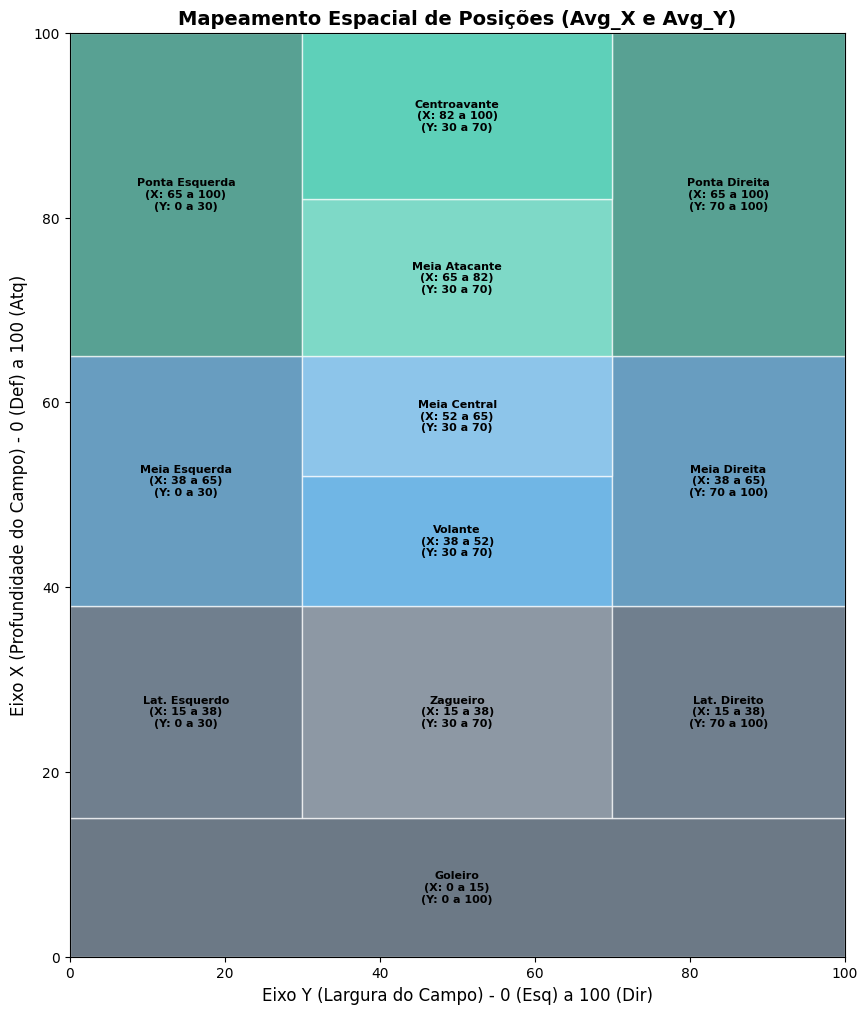

In [44]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def desenhar_mapa_posicoes():
    fig, ax = plt.subplots(figsize=(10, 12))

    # Desenhar o contorno do campo (X de 0 a 100, Y de 0 a 100)
    # Aqui vamos plotar X no eixo Y (vertical no gráfico) para simular a visão de cima (Defesa embaixo, Ataque em cima)
    # E Y no eixo X (horizontal no gráfico)

    # Função auxiliar para desenhar as caixas, agora configurada para mostrar X e Y automaticamente
    def adicionar_zona(y_min, y_max, x_min, x_max, cor, texto):
        rect = patches.Rectangle((y_min, x_min), y_max - y_min, x_max - x_min,
                                 linewidth=1, edgecolor='white', facecolor=cor, alpha=0.7)
        ax.add_patch(rect)

        # Formatar o rótulo incluindo as coordenadas X e Y
        label = f"{texto}\n(X: {x_min} a {x_max})\n(Y: {y_min} a {y_max})"

        # Fonte reduzida para 8 para acomodar as 3 linhas sem vazar da caixa
        ax.text(y_min + (y_max - y_min)/2, x_min + (x_max - x_min)/2, label,
                color='black', weight='bold', fontsize=8, ha='center', va='center')

    # 1. Goleiro (X: 0 a 15)
    adicionar_zona(0, 100, 0, 15, '#2e4053', 'Goleiro')

    # 2. Defesa (X: 15 a 38)
    adicionar_zona(0, 30, 15, 38, '#34495e', 'Lat. Esquerdo')
    adicionar_zona(30, 70, 15, 38, '#5d6d7e', 'Zagueiro')
    adicionar_zona(70, 100, 15, 38, '#34495e', 'Lat. Direito')

    # 3. Meio-campo recuado / Volante (X: 38 a 52)
    adicionar_zona(0, 30, 38, 65, '#2874a6', 'Meia Esquerda')
    adicionar_zona(30, 70, 38, 52, '#3498db', 'Volante')
    adicionar_zona(70, 100, 38, 65, '#2874a6', 'Meia Direita')

    # 4. Meia Central (X: 52 a 65)
    adicionar_zona(30, 70, 52, 65, '#5dade2', 'Meia Central')

    # 5. Meio-campo ofensivo (X: 65 a 82)
    adicionar_zona(0, 30, 65, 100, '#117a65', 'Ponta Esquerda')
    adicionar_zona(30, 70, 65, 82, '#48c9b0', 'Meia Atacante')
    adicionar_zona(70, 100, 65, 100, '#117a65', 'Ponta Direita')

    # 6. Ataque (X: 82 a 100)
    adicionar_zona(30, 70, 82, 100, '#1abc9c', 'Centroavante')

    # Configurações do gráfico
    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.set_xlabel('Eixo Y (Largura do Campo) - 0 (Esq) a 100 (Dir)', fontsize=12)
    ax.set_ylabel('Eixo X (Profundidade do Campo) - 0 (Def) a 100 (Atq)', fontsize=12)
    ax.set_title('Mapeamento Espacial de Posições (Avg_X e Avg_Y)', fontsize=14, weight='bold')

    plt.grid(False)
    plt.savefig('mapa_posicoes_tcc.png', dpi=300, bbox_inches='tight')
    plt.show()

desenhar_mapa_posicoes()